# Machine Learning

In [2]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
import pandas as pd

In [3]:
load_dotenv()
user = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")
host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT")
database = os.getenv("DB_NAME")

try:
    engine = create_engine(f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}")
    query="""
        select
            order_purchase_timestamp::date as order_day,
        sum(price) as revenue
        from
            analytics.fact_orders
        where 
            order_purchase_timestamp is not null
        group by 
            order_day  
        order by 
        order_day
    """

    revenue_df = pd.read_sql(query, con=engine)
    print("---Data set details---")
    print(revenue_df.head(5))

except Exception as e:
    print(f"Detail error: {e}")
finally:
    engine.dispose()

---Data set details---
    order_day  revenue
0  2016-09-04    72.89
1  2016-09-05    59.50
2  2016-09-15   134.97
3  2016-10-02   100.00
4  2016-10-03   463.48


In [4]:
revenue_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 616 entries, 0 to 615
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   order_day  616 non-null    object 
 1   revenue    616 non-null    float64
dtypes: float64(1), object(1)
memory usage: 9.8+ KB


In [5]:
revenue_df["order_day"] = pd.to_datetime(revenue_df["order_day"])
revenue_df.set_index('order_day', inplace=True)

In [6]:
revenue_df.describe()

,revenue
count,616.000000
mean,22064.356656
std,12594.027039
min,10.900000
25%,13018.205000
50%,20511.455000
75%,29591.957500
max,152653.740000


## Feature Engineering

In [7]:
revenue_df["day_of_week"] = revenue_df.index.day_of_week
revenue_df["is_weekend"] = (revenue_df.index.day_of_week >=5).astype(int)
revenue_df["lag_7"] = revenue_df["revenue"].shift(7)
revenue_df["rolling_mean_7"] =(
    revenue_df["revenue"]
    .rolling(7)
    .mean()
)
revenue_df["lag_14"] = revenue_df["revenue"].shift(14)
revenue_df["rolling_mean_14"] =(
    revenue_df["revenue"]
    .rolling(14)
    .mean()
)
revenue_df

,revenue,day_of_week,is_weekend,lag_7,rolling_mean_7,lag_14,rolling_mean_14
order_day,,,,,,,
2016-09-04,72.89,6,1,NaN,NaN,NaN,NaN
2016-09-05,59.50,0,0,NaN,NaN,NaN,NaN
2016-09-15,134.97,3,0,NaN,NaN,NaN,NaN
2016-10-02,100.00,6,1,NaN,NaN,NaN,NaN
2016-10-03,463.48,0,0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2018-08-26,8070.71,6,1,25487.39,18062.041429,31524.21,26574.565714
2018-08-27,5345.91,0,0,34479.50,13900.100000,38613.13,24198.335714
2018-08-28,3673.91,1,0,26323.06,10664.507143,44192.84,21304.126429


In [8]:
revenue_df.dropna(inplace=True)

In [9]:
revenue_df

,revenue,day_of_week,is_weekend,lag_7,rolling_mean_7,lag_14,rolling_mean_14
order_day,,,,,,,
2017-01-06,916.38,4,0,7960.51,3431.948571,72.89,3644.736429
2017-01-07,1351.90,5,1,7228.05,2592.498571,59.50,3737.050714
2017-01-08,709.58,6,1,8441.85,1487.888571,134.97,3778.094286
2017-01-09,673.79,0,0,3336.99,1107.431429,100.00,3819.079286
2017-01-10,1434.87,1,0,3692.57,784.902857,463.48,3888.464286
...,...,...,...,...,...,...,...
2018-08-26,8070.71,6,1,25487.39,18062.041429,31524.21,26574.565714
2018-08-27,5345.91,0,0,34479.50,13900.100000,38613.13,24198.335714
2018-08-28,3673.91,1,0,26323.06,10664.507143,44192.84,21304.126429


## Exploratory analysis

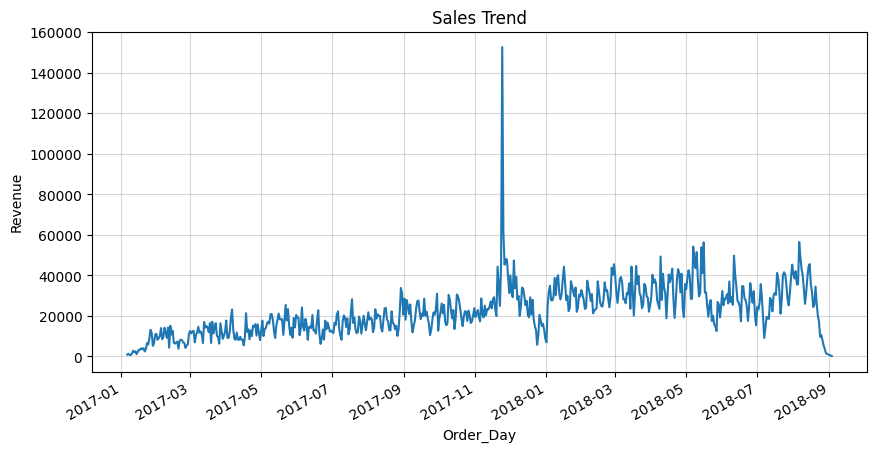

In [10]:
axis= revenue_df["revenue"].plot(figsize=(10,5))
axis.set_xlabel("Order_Day")
axis.set_ylabel("Revenue")
axis.set_title("Sales Trend")
axis.grid(True, alpha=0.5)

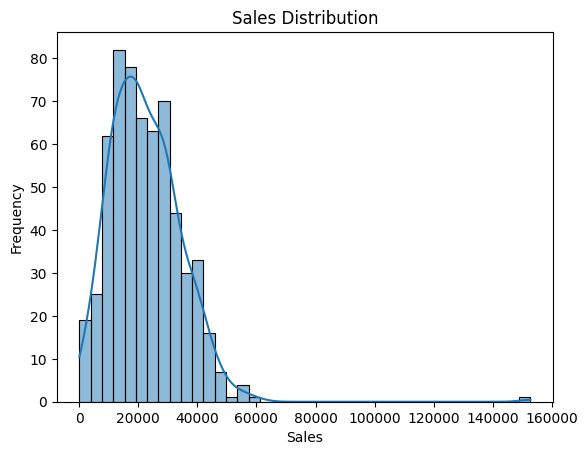

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(revenue_df["revenue"], kde=True,)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

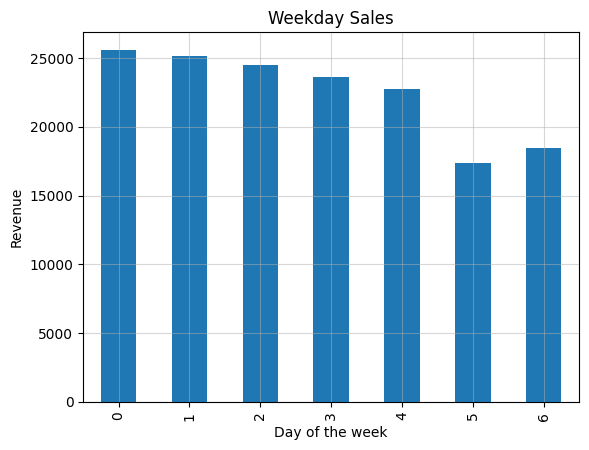

In [12]:
axis= revenue_df.groupby("day_of_week")["revenue"].mean().plot(kind="bar")
axis.set_xlabel("Day of the week")
axis.set_ylabel("Revenue")
axis.set_title("Weekday Sales")
axis.grid(True, alpha=0.5)



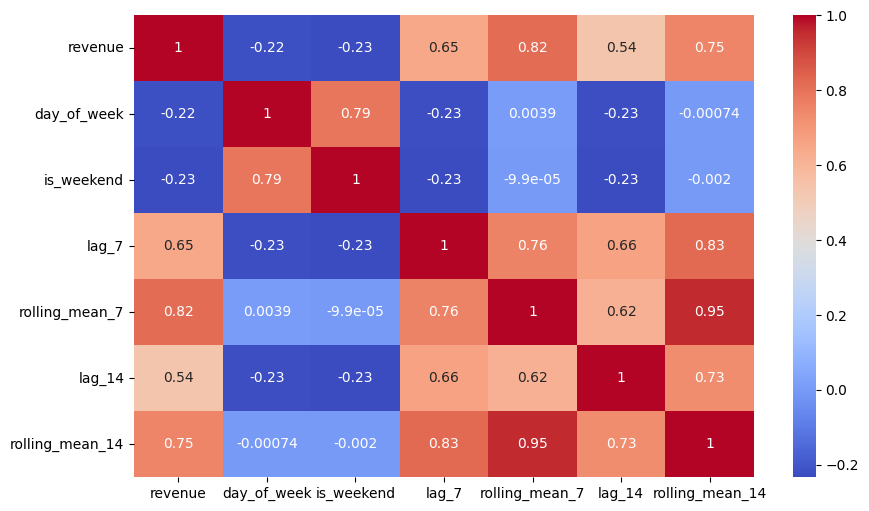

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(
    revenue_df.corr(),
    annot=True,
    cmap="coolwarm")
plt.show()

In [14]:
ml_df = revenue_df[["revenue", "lag_7",	"rolling_mean_7", "lag_14",	"rolling_mean_14"]]

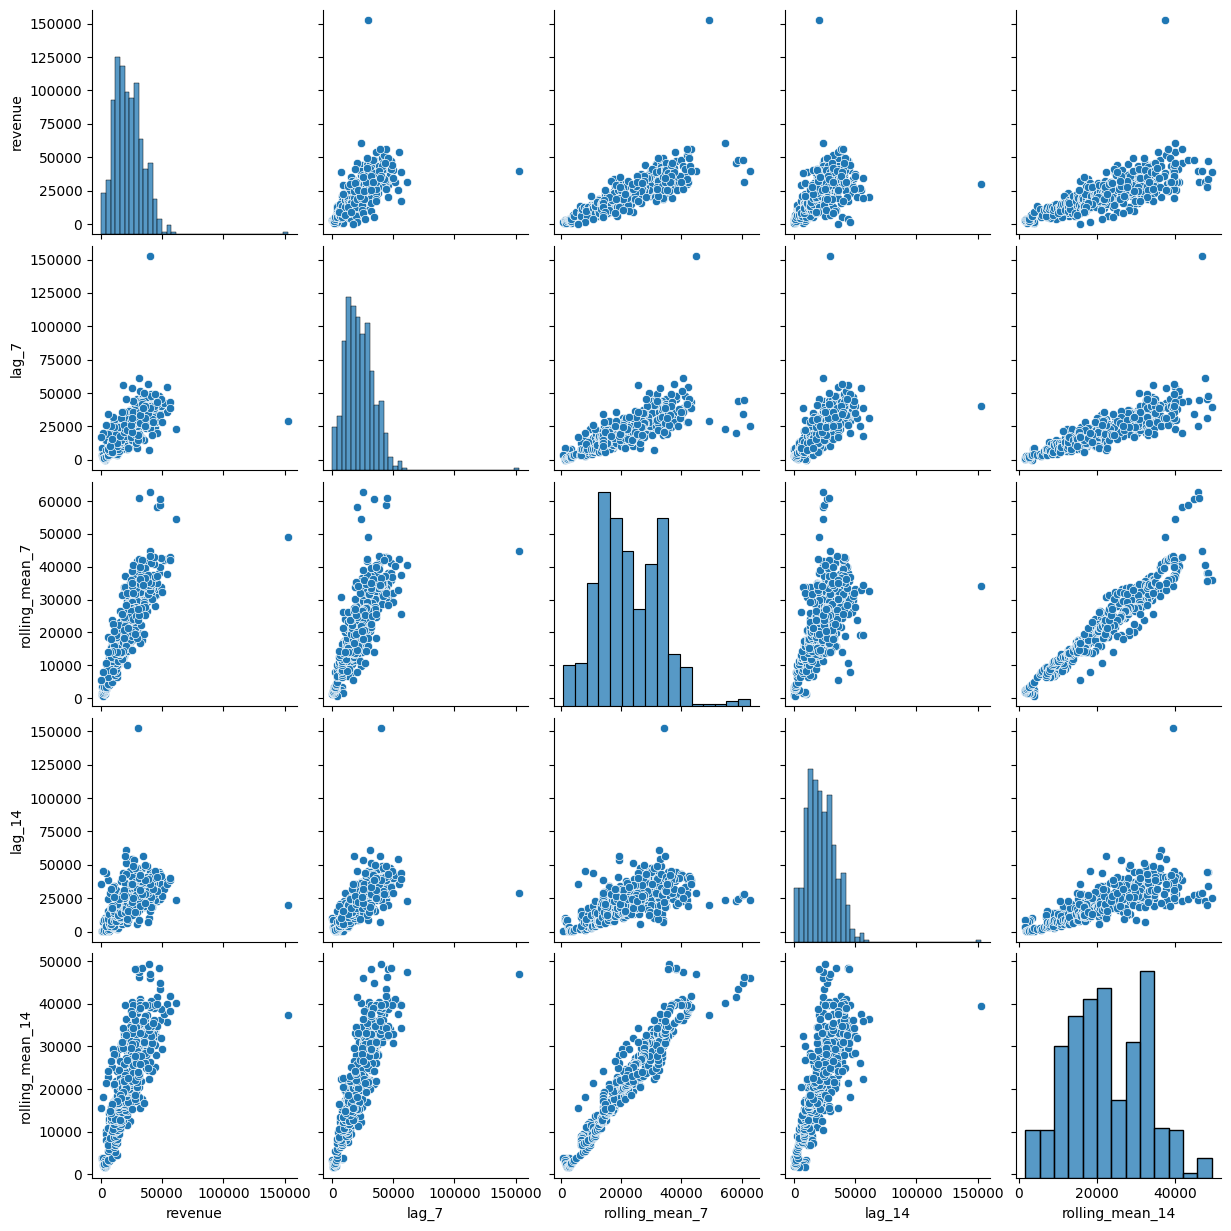

In [15]:
sns.pairplot(ml_df, height=2.5)
plt.show()

In [16]:
x = ml_df.drop("revenue", axis=1)
y = ml_df["revenue"]

In [17]:
train_size = int(len(x)*0.80)

In [18]:
X_train = x.iloc[:train_size]
X_test = x.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

## Model training phase

### Linear Regression

In [19]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Random Forest

In [20]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor( n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

### XGBoost

In [21]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42)

xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

## Prediction phase

In [22]:
lr_predict = lr_model.predict(X_test)

rf_predict = rf_model.predict(X_test)

xgb_predict = xgb_model.predict(X_test)

## Metrics

In [23]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error)
import numpy as np

def evaluate_model(y_true, x_predict):
    mae = mean_absolute_error(y_true, x_predict)
    mse = mean_squared_error(y_true, x_predict)
    mape = mean_absolute_percentage_error(y_true, x_predict)
    return mae, mse, mape

In [24]:
mae_lr, mse_lr, mape_lr = evaluate_model(y_test, lr_predict) 

mae_rf, mse_rf, mape_rf = evaluate_model(y_test, rf_predict)

mae_xgb, mse_xgb, mape_xgb = evaluate_model(y_test, xgb_predict)

In [25]:
result = pd.DataFrame({"MODELS": ["Linear Regression", "Random Forest", "XGBoost"], 
                        "MAE": [mae_lr, mae_rf, mae_xgb], 
                        "MSE": [mse_lr, mse_rf, mse_xgb], 
                        "MAPE": [mape_lr, mape_rf, mape_xgb]})

In [26]:
result

,MODELS,MAE,MSE,MAPE
0,Linear Regression,5560.286241,4.446980e+07,0.566752
1,Random Forest,5672.635392,4.770541e+07,0.799910
2,XGBoost,6059.774513,5.500820e+07,0.794993


In [27]:
final_df = y_test.to_frame(name="Real_result")

In [28]:
final_df[["LR_values", "RF_values", "XGB_values"]] = list(zip(lr_predict, rf_predict,xgb_predict))

In [29]:
final_df

,Real_result,LR_values,RF_values,XGB_values
order_day,,,,
2018-05-02,38557.72,33008.323483,37211.4440,37784.343750
2018-05-03,42497.77,34341.469582,35687.3784,36342.550781
2018-05-04,39730.93,32901.368143,31265.1074,30338.068359
2018-05-05,28306.45,29744.022244,24988.0141,22187.376953
2018-05-06,28565.97,31981.867268,27176.2474,29773.113281
...,...,...,...,...
2018-08-26,8070.71,15513.764391,14785.7994,13262.300781
2018-08-27,5345.91,13658.706379,12048.1308,10531.039062
2018-08-28,3673.91,10811.666483,11788.4328,12338.118164


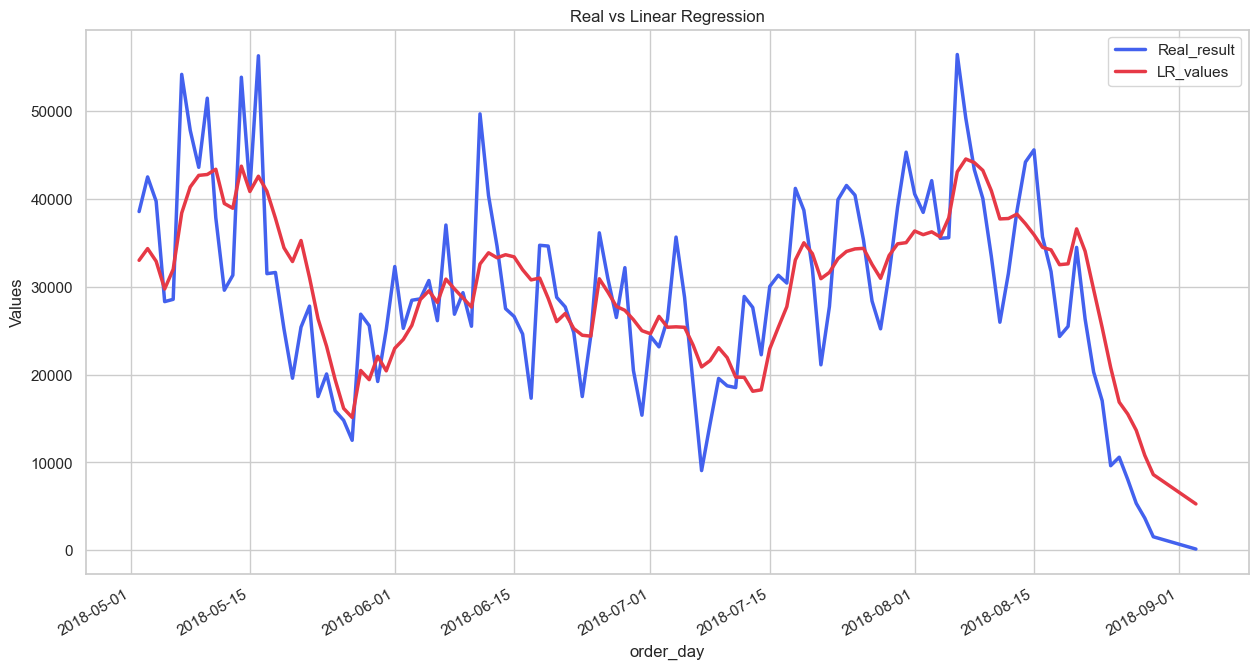

In [30]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(15, 8))

final_df[["Real_result", "LR_values"]].plot(
    ax=plt.gca(), 
    color=["#4361ee", "#e63946"], 
    linewidth=2.5
)
plt.title("Real vs Linear Regression")
plt.ylabel("Values")

plt.savefig(
    r"C:\Professional_project\Olist_Machine_Learning\Images\real_vs_linear_regr.png",
    bbox_inches="tight")

plt.show()